In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    ConfusionMatrixDisplay
)

# =========================
# 1️⃣ Load data (Option 2)
# =========================

X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()



In [12]:
# =========================
# 2️⃣ Train model
# =========================

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [13]:
# =========================
# 3️⃣ Default predictions (threshold = 0.5)
# =========================

y_pred_default = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=== RESULTS WITH DEFAULT THRESHOLD (0.5) ===")
print(classification_report(y_test, y_pred_default))
print("AUC:", roc_auc_score(y_test, y_prob))

=== RESULTS WITH DEFAULT THRESHOLD (0.5) ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

AUC: 0.8423932418817328


In [14]:
# =========================
# 4️⃣ Find best threshold (maximize F1) – Exploratory
# =========================

thresholds = np.arange(0.01, 0.99, 0.01)
best_threshold = 0
best_f1 = 0

for t in thresholds:
    y_pred_custom = (y_prob >= t).astype(int)
    score = f1_score(y_test, y_pred_custom)
    
    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("\nBest threshold (F1 maximized):", best_threshold)
print("Best F1:", best_f1)



Best threshold (F1 maximized): 0.27
Best F1: 0.6207627118644068


In [15]:
# =========================
# 5️⃣ Predictions with optimal threshold
# =========================

y_pred_best = (y_prob >= best_threshold).astype(int)

print("\n=== RESULTS WITH OPTIMAL THRESHOLD ===")
print(classification_report(y_test, y_pred_best))
print("AUC (unchanged):", roc_auc_score(y_test, y_prob))


=== RESULTS WITH OPTIMAL THRESHOLD ===
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409

AUC (unchanged): 0.8423932418817328


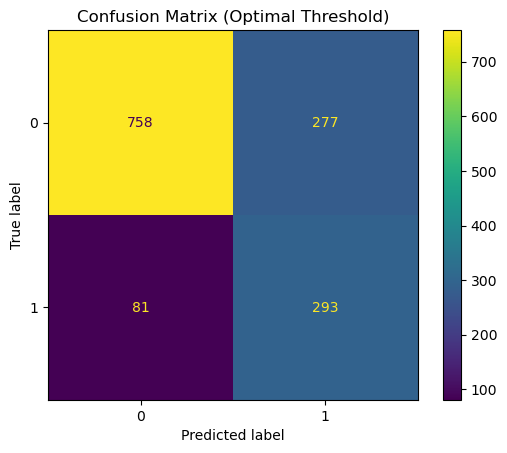

In [16]:
# =========================
# 6️⃣ Confusion Matrix
# =========================

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.title("Confusion Matrix (Optimal Threshold)")
plt.show()

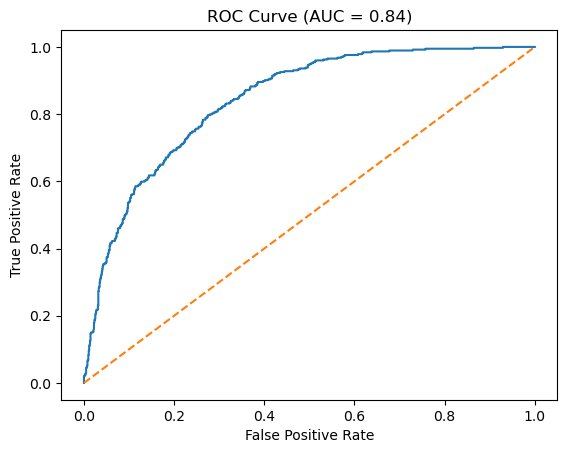

In [17]:
# =========================
# 7️⃣ ROC Curve
# =========================

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title(f"ROC Curve (AUC = {auc_score:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


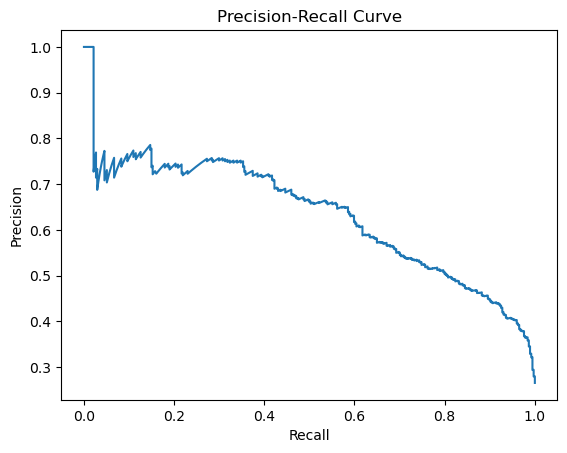

In [18]:
# =========================
# 8️⃣ Precision-Recall Curve
# =========================

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


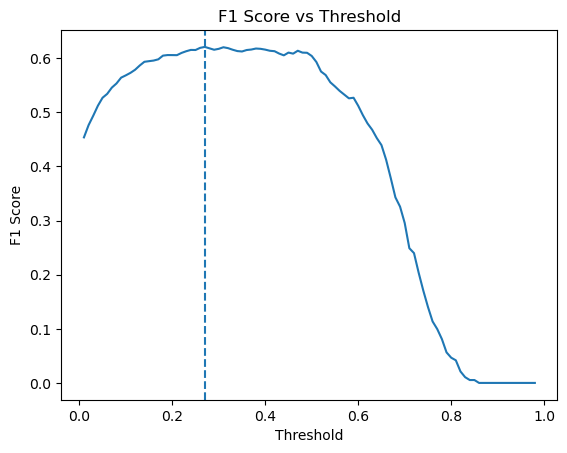

In [19]:
# =========================
# 9️⃣ F1 vs Threshold Graph
# =========================

f1_scores = []

for t in thresholds:
    y_pred_custom = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_custom))

plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, linestyle='--')
plt.title("F1 Score vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.show()